In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.impute import SimpleImputer

In [ ]:
df = pd.read_csv('bank-full.csv',sep=';')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [ ]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [ ]:
features = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous']
target = ['y']

X = df[features]
y = df[target]

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
df.duplicated().value_counts()

,count
False,45211


In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [ ]:
# Replace unknown values to NaN
string = ['unknown','Unknown']
df = df.replace(string, np.nan)


In [ ]:
df.isna().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


In [ ]:
df = df.drop(columns='poutcome')

In [ ]:
# Impute NaN for education with "most frequent"
cat_imputer = SimpleImputer(strategy='most_frequent')
df['education'] = cat_imputer.fit_transform(df[['education']]).ravel()

In [ ]:
# Impute NaN for job with "most frequent"
df['job'] = cat_imputer.fit_transform(df[['job']]).ravel()

In [ ]:
# Same for contact
df['contact'] = cat_imputer.fit_transform(df[['contact']]).ravel()

In [ ]:
# Education and month feature preprocessed ordinaly
cat_cols = ['job','marital','default','housing','loan','contact']
df_clean = pd.get_dummies(data=df,columns=cat_cols, dtype=int, drop_first=True)

In [ ]:
df_clean['education'].unique()

array(['tertiary', 'secondary', 'primary'], dtype=object)

In [ ]:
df_clean['month'].unique()

array(['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb',
       'mar', 'apr', 'sep'], dtype=object)

In [ ]:
education_orderings = ['primary','secondary','tertiary']
month_ordering = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

encoder = OrdinalEncoder(categories=[education_orderings,month_ordering])

df_clean[['education','month']] = encoder.fit_transform(df_clean[['education','month']])
df_clean['month'] = df_clean['month'] + 1


In [ ]:
# Check correlation
# Drop y and then add back later
df_clean_corr = df_clean.drop('y',axis=1)
df_clean_corr.corr()


,age,education,balance,day,month,duration,campaign,pdays,previous,job_blue-collar,...,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,default_yes,housing_yes,loan_yes,contact_telephone
age,1.000000,-0.164888,0.097783,-0.009120,0.092903,-0.004648,0.004760,-0.023758,0.001288,-0.033926,...,-0.065780,-0.197302,-0.068632,0.000412,0.286257,-0.427817,-0.017879,-0.185513,-0.015655,0.170349
education,-0.164888,1.000000,0.067184,0.025931,0.071938,0.002635,0.003703,0.004264,0.025175,-0.412379,...,-0.086366,0.010750,0.065866,-0.031195,-0.144830,0.159197,-0.011539,-0.075157,-0.025282,-0.070190
balance,0.097783,0.067184,1.000000,0.004503,0.094605,0.021560,-0.014578,0.003435,0.016674,-0.046182,...,-0.038151,0.001233,-0.016183,0.009023,0.025708,-0.012537,-0.066745,-0.068768,-0.084350,0.037999
day,-0.009120,0.025931,0.004503,1.000000,0.101989,-0.030206,0.162490,-0.093044,-0.051710,-0.024804,...,-0.006531,-0.015894,0.032517,-0.006382,0.007102,-0.007412,0.009424,-0.027982,0.011370,0.023652
month,0.092903,0.071938,0.094605,0.101989,1.000000,-0.011866,0.054868,-0.108940,-0.035600,-0.083915,...,-0.040318,-0.018733,0.037859,-0.040271,0.062925,-0.068586,0.014989,-0.173887,0.021638,0.037628
duration,-0.004648,0.002635,0.021560,-0.030206,-0.011866,1.000000,-0.084570,-0.001565,0.001203,0.008312,...,0.001427,-0.006504,-0.009176,0.020322,-0.022683,0.020328,-0.010021,0.005075,-0.012412,-0.023201
campaign,0.004760,0.003703,-0.014578,0.162490,0.054868,-0.084570,1.000000,-0.088628,-0.032855,0.011591,...,-0.004671,-0.021813,0.020739,-0.018448,0.031371,-0.023120,0.016822,-0.023599,0.009980,0.053895
pdays,-0.023758,0.004264,0.003435,-0.093044,-0.108940,-0.001565,-0.088628,1.000000,0.454820,0.016910,...,0.005710,0.024486,-0.013478,-0.010411,-0.027600,0.027943,-0.029979,0.124178,-0.022754,0.016006
previous,0.001288,0.025175,0.016674,-0.051710,-0.035600,0.001203,-0.032855,0.454820,1.000000,-0.018654,...,-0.010926,0.023556,-0.001123,-0.008504,-0.012691,0.017006,-0.018329,0.037076,-0.011043,0.028097
job_blue-collar,-0.033926,-0.412379,-0.046182,-0.024804,-0.083915,0.008312,0.011591,0.016910,-0.018654,1.000000,...,-0.169730,-0.077669,-0.239808,-0.091922,0.123983,-0.088985,0.008955,0.161249,0.011982,0.002812


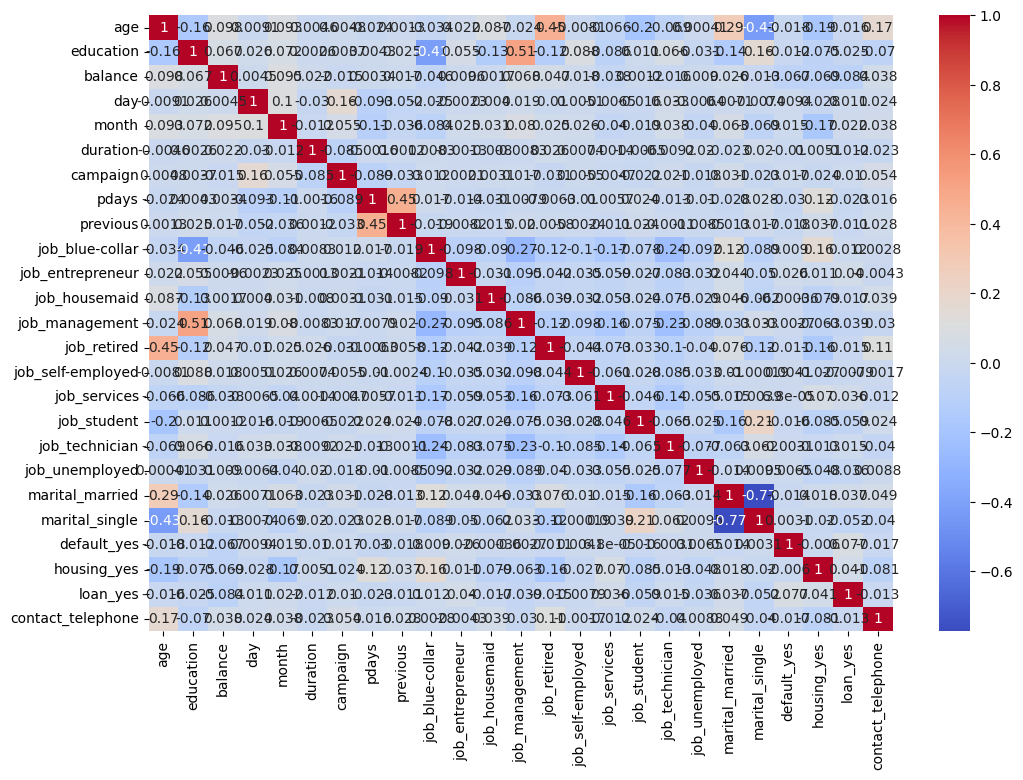

In [ ]:
# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df_clean_corr.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# No irrelevant features
X = df_clean.drop('y',axis=1)
y = df_clean['y']

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (31647, 25) Test shape: (13564, 25)


In [ ]:
# Normalize X
scaler = StandardScaler()
scaled = scaler.fit_transform(X)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

In [ ]:
# Parameters: 1) max_iterations, 2)
lr = LogisticRegression(max_iter=2000)

model = lr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_pred = model.predict(X_test)

print('accuracy score:', accuracy_score(y_test, y_pred))
print('precision score:', precision_score(y_test, y_pred))
print('recall score:', recall_score(y_test, y_pred))
print('f-1 score:', f1_score(y_test, y_pred))

accuracy score: 0.8884547331170746
precision score: 0.5714285714285714
recall score: 0.2127659574468085
f-1 score: 0.31007751937984496


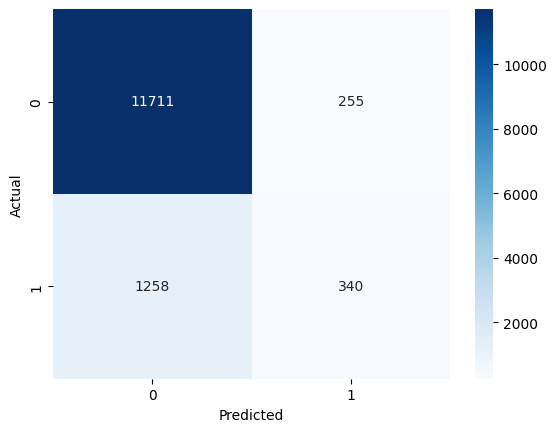

In [ ]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ROC Curve, review why I only get the prob of being positive class
y_pred_prob_1 = model.predict_proba(X_test)[:,1]
y_pred_prob_1

array([0.02778532, 0.05264544, 0.11363663, ..., 0.13539482, 0.05483582,
       0.30566921])

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_1)
auc_score = roc_auc_score(y_test, y_pred_prob_1)

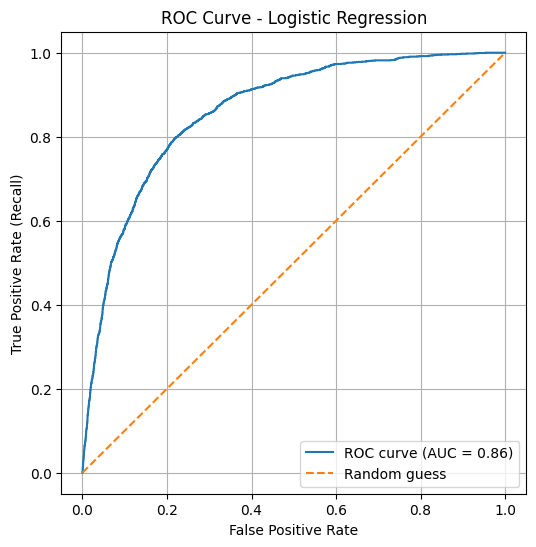

In [ ]:
# Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# INTERPRETATION OF THIS ROC CURVE!
#“The ROC curve shows the logistic regression model performs well in distinguishing between subscribers and non-subscribers, with an AUC of 0.80.
#This means there is an 80% chance the model ranks a randomly chosen subscriber higher than a non-subscriber.
#The curve rises steeply at low false-positive rates, which is valuable for the Bank Marketing Campaign because the bank can prioritize customers who are most likely to subscribe, reducing wasted calls and improving campaign efficiency.
#Overall, the model is effective and aligned with expectations for this dataset.”

In [ ]:
# Definition of Log Loss: "........."
# Log Loss (a.k.a. Logistic Loss or Cross-Entropy Loss) is a metric used to evaluate classification models that output probabilities.
# It measures how close the predicted probabilities are to the actual labels.

from sklearn.metrics import log_loss
log_loss(y_test, y_pred_prob_1)

0.27406373523714805

In [ ]:
# What does this metric actually mean? Same as accuracy
model.score(X_test,y_test)

0.8884547331170746

In [ ]:
# Setting up different thresholds to increase performance

# Decision Tree

In [ ]:
df_dt = df_clean.copy()
df_dt

,age,education,balance,day,month,duration,campaign,pdays,previous,y,...,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,default_yes,housing_yes,loan_yes,contact_telephone
0,58,2.0,2143,5,5.0,261,1,-1,0,no,...,0,0,0,0,1,0,0,1,0,0
1,44,1.0,29,5,5.0,151,1,-1,0,no,...,0,0,1,0,0,1,0,1,0,0
2,33,1.0,2,5,5.0,76,1,-1,0,no,...,0,0,0,0,1,0,0,1,1,0
3,47,1.0,1506,5,5.0,92,1,-1,0,no,...,0,0,0,0,1,0,0,1,0,0
4,33,1.0,1,5,5.0,198,1,-1,0,no,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,2.0,825,17,11.0,977,3,-1,0,yes,...,0,0,1,0,1,0,0,0,0,0
45207,71,0.0,1729,17,11.0,456,2,-1,0,yes,...,0,0,0,0,0,0,0,0,0,0
45208,72,1.0,5715,17,11.0,1127,5,184,3,yes,...,0,0,0,0,1,0,0,0,0,0
45209,57,1.0,668,17,11.0,508,4,-1,0,no,...,0,0,0,0,1,0,0,0,0,1


In [ ]:
# Label Encoder y
le = LabelEncoder()
df_dt['y'] = le.fit_transform(y)

In [ ]:
X = df_dt.drop('y', axis=1)
y = df_dt['y']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Should I fine tune these parameters?
# DT Parameters: 1) criterion, 2) max_depth, 3) min_samples_split, 4) min_samples_leaf

param_grid = {'criterion': ['entropy', 'gini'],
               'max_depth': [3, 4, 5, 6, None],
               'min_samples_split': [2, 5, 10],
               'min_samples_leaf': [1, 2, 5]}

grid_DT = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_DT.fit(X_train, y_train)

print('Best Parameters:', grid_DT.best_params_)
# classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
# clf = classifier.fit(X_train, y_train)

Best Parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
best_DT = grid_DT.best_estimator_

In [ ]:
y_grid_train = best_DT.predict(X_train)
y_grid_pred = best_DT.predict(X_test)

acc_train = accuracy_score(y_train, y_grid_train)
acc_test = accuracy_score(y_test, y_grid_pred)

print('accuracy_train:', acc_train)
print('accuracy_test:', acc_test)

accuracy_train: 0.9008120832938351
accuracy_test: 0.890002948982601


In [ ]:
# Accuracy, Precision, Recall, F-1 for not tuned parameters
# print('Accuracy_DT:', accuracy_score(y_test, y_pred))
# print('Precision_DT:', precision_score(y_test, y_pred))
# print('Recall_DT:', recall_score(y_test, y_pred))

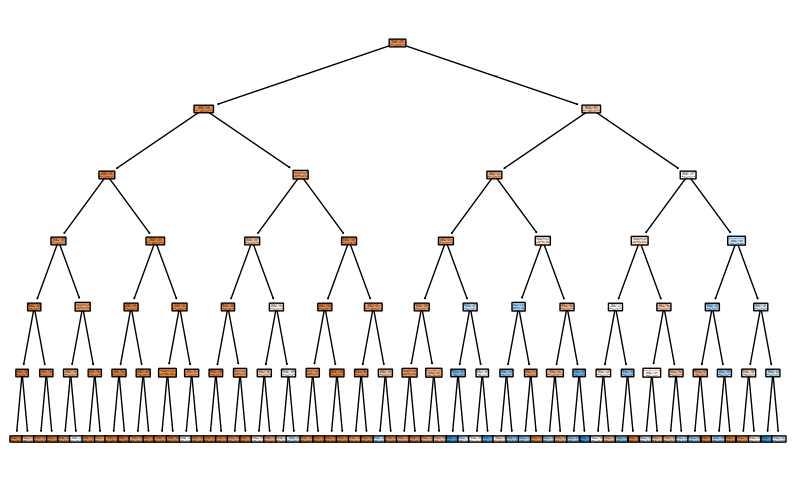

In [ ]:
# Tree Plot with fitted data to see the split criteria
plt.figure(figsize=(10,6))
plot_tree(best_DT,
          feature_names=X_train.columns,
          class_names=["No","Yes"],
          filled=True,
          rounded=True)
plt.show()

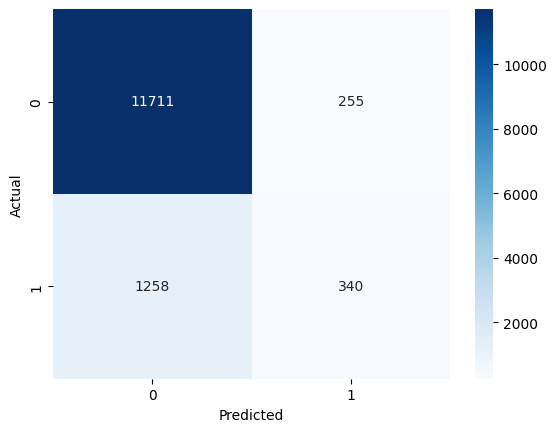

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test,y_pred)
cm

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest

In [ ]:
df_rf = df_clean.copy()
df_rf

,age,education,balance,day,month,duration,campaign,pdays,previous,y,...,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,default_yes,housing_yes,loan_yes,contact_telephone
0,58,2.0,2143,5,5.0,261,1,-1,0,no,...,0,0,0,0,1,0,0,1,0,0
1,44,1.0,29,5,5.0,151,1,-1,0,no,...,0,0,1,0,0,1,0,1,0,0
2,33,1.0,2,5,5.0,76,1,-1,0,no,...,0,0,0,0,1,0,0,1,1,0
3,47,1.0,1506,5,5.0,92,1,-1,0,no,...,0,0,0,0,1,0,0,1,0,0
4,33,1.0,1,5,5.0,198,1,-1,0,no,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,2.0,825,17,11.0,977,3,-1,0,yes,...,0,0,1,0,1,0,0,0,0,0
45207,71,0.0,1729,17,11.0,456,2,-1,0,yes,...,0,0,0,0,0,0,0,0,0,0
45208,72,1.0,5715,17,11.0,1127,5,184,3,yes,...,0,0,0,0,1,0,0,0,0,0
45209,57,1.0,668,17,11.0,508,4,-1,0,no,...,0,0,0,0,1,0,0,0,0,1


In [ ]:
# Label Encoder
le = LabelEncoder()
df_rf['y'] = le.fit_transform(y)
df_rf

,age,education,balance,day,month,duration,campaign,pdays,previous,y,...,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,default_yes,housing_yes,loan_yes,contact_telephone
0,58,2.0,2143,5,5.0,261,1,-1,0,0,...,0,0,0,0,1,0,0,1,0,0
1,44,1.0,29,5,5.0,151,1,-1,0,0,...,0,0,1,0,0,1,0,1,0,0
2,33,1.0,2,5,5.0,76,1,-1,0,0,...,0,0,0,0,1,0,0,1,1,0
3,47,1.0,1506,5,5.0,92,1,-1,0,0,...,0,0,0,0,1,0,0,1,0,0
4,33,1.0,1,5,5.0,198,1,-1,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,2.0,825,17,11.0,977,3,-1,0,1,...,0,0,1,0,1,0,0,0,0,0
45207,71,0.0,1729,17,11.0,456,2,-1,0,1,...,0,0,0,0,0,0,0,0,0,0
45208,72,1.0,5715,17,11.0,1127,5,184,3,1,...,0,0,0,0,1,0,0,0,0,0
45209,57,1.0,668,17,11.0,508,4,-1,0,0,...,0,0,0,0,1,0,0,0,0,1


In [ ]:
df_rf['y'].value_counts()

,count
y,
0,39922
1,5289


In [ ]:
X = df_rf.drop('y', axis=1)
y = df_rf['y']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.7, random_state=42)

In [ ]:
# Parameters: 1) n_estimators, 2) max_depth, 3) min_samples_split, 4) min_samples_leaf
rf = RandomForestClassifier(random_state=42)

In [ ]:
param_grid = {'n_estimators': [100, 200, 300, 500],
              'max_depth': [3, 5, 8, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4]}

grid_rf = GridSearchCV(rf, param_grid, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print('Best Parameters:', grid_rf.best_params_)
print('Best Score:', grid_rf.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best Score: 0.9016338242903539


In [ ]:
best_rf = grid_rf.best_estimator_

In [ ]:
y_grid_train_rf = best_rf.predict(X_train)
y_grid_test_rf = best_rf.predict(X_test)

print('Accuracy Train:', accuracy_score(y_train, y_grid_train_rf))
print('Accuracy Test:', accuracy_score(y_test, y_grid_test_rf))

Accuracy Train: 0.9694441811230132
Accuracy Test: 0.9004718372161604


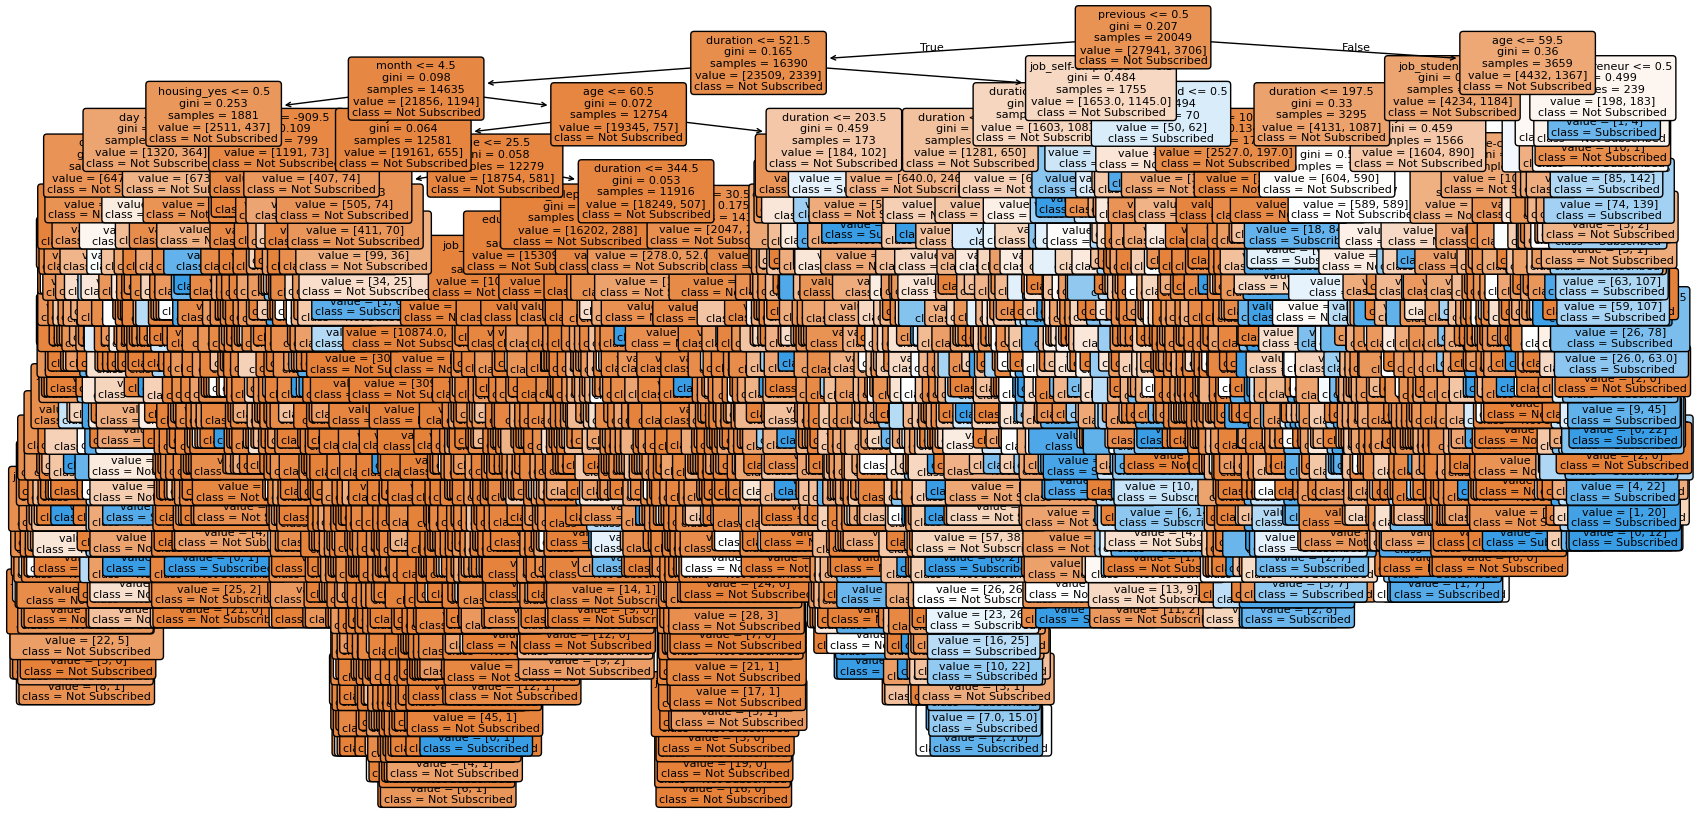

In [ ]:
# Plotting the tree
one_tree = best_rf.estimators_[0]

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(one_tree,
          feature_names=X.columns,
          class_names=['Not Subscribed', 'Subscribed'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.show()

# XGBoost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
# Parameters: 1) n_estimators=300, 2) learning_rate, 3) max_depth, 4) objective, 5) eval_metric

xgb = XGBClassifier(objective='binary:logistic', random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_train = xgb.predict(X_train)
y_pred = xgb.predict(X_test)

print('Accuracy Train:', accuracy_score(y_train, y_pred_train))
print('Accuracy Test:', accuracy_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:31:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy Train: 0.9568995481404241
Accuracy Test: 0.9029047478619876


# K-NN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# If scaling is needed, maybe I need to change X to X_scaled.
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=42)

In [ ]:
# Scaling

scaler_knn = StandardScaler()
X_train_knn = scaler.fit_transform(X_train)
X_test_knn = scaler.transform(X_test)

In [ ]:
# Parameters: 1) n_neighbors, 2) weights, 3) metric (euclidean, minkowski (p=2), manhattan)
knn = KNeighborsClassifier(n_neighbors = 5, metric ='euclidean')
knn.fit(X_train, y_train)

y_pred_train = knn.predict(X_train)
y_pred = knn.predict(X_test)


print('Accuracy Train:', accuracy_score(y_train, y_pred_train))
print('Accuracy Test:', accuracy_score(y_test, y_pred))

Accuracy Train: 0.9107656333933706
Accuracy Test: 0.8792391624889413


# Neural Net - Pytorch

In [ ]:
# Heavy class imbalance caused ANN to perform very badly.

In [ ]:
# pip install torch

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 1. Prepare data
# X_train, X_test, y_train, y_test are numpy arrays
X_train_t = torch.from_numpy(X_train.to_numpy()).float()
y_train_t = torch.from_numpy(y_train.to_numpy()).float().view(-1, 1)  # (N, 1) for BCEWithLogitsLoss

X_test_t = torch.from_numpy(X_test.to_numpy()).float()
y_test_t = torch.from_numpy(y_test.to_numpy()).float().view(-1, 1)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the model
class SimpleANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)       # output: logits for binary classification
        )

    def forward(self, x):
        return self.net(x)

model = SimpleANN(input_dim=X_train.shape[1]).to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
from math import isnan

n_epochs = 20

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # forward
        logits = model(xb)
        loss = criterion(logits, yb)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    # --- evaluation ---
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            correct += (preds == yb).sum().item()
            total   += yb.size(0)

    acc = correct / total
    print(f"Epoch {epoch+1:02d} | loss={epoch_loss:.4f} | test_acc={acc:.4f}")

Epoch 01 | loss=0.6563 | test_acc=0.8856
Epoch 02 | loss=0.3483 | test_acc=0.8841
Epoch 03 | loss=0.3086 | test_acc=0.8866
Epoch 04 | loss=0.2948 | test_acc=0.8845
Epoch 05 | loss=0.2851 | test_acc=0.8861
Epoch 06 | loss=0.2822 | test_acc=0.8849
Epoch 07 | loss=0.2773 | test_acc=0.8854
Epoch 08 | loss=0.2748 | test_acc=0.8833
Epoch 09 | loss=0.2744 | test_acc=0.8871
Epoch 10 | loss=0.2712 | test_acc=0.8849
Epoch 11 | loss=0.2702 | test_acc=0.8837
Epoch 12 | loss=0.2693 | test_acc=0.8838
Epoch 13 | loss=0.2693 | test_acc=0.8826
Epoch 14 | loss=0.2696 | test_acc=0.8835
Epoch 15 | loss=0.2662 | test_acc=0.8829
Epoch 16 | loss=0.2658 | test_acc=0.8833
Epoch 17 | loss=0.2644 | test_acc=0.8870
Epoch 18 | loss=0.2638 | test_acc=0.8826
Epoch 19 | loss=0.2633 | test_acc=0.8874
Epoch 20 | loss=0.2624 | test_acc=0.8832


# Neural Net - TensorFlow

In [ ]:
# You would want to always scale the data to improve perfomance, optimization and speed up the training process.

import tensorflow as tf
from tensorflow import keras

input_dim = X_train_scaled.shape[1]

# Define the model
model_tf = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation="sigmoid")  # directly output probability for binary classification
])

# Compile
model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stoppage when the performance stabilizes
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

# Train
history = model_tf.fit(
    X_train, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

# Evaluate
test_loss, test_acc = model_tf.evaluate(X_test_scaled, y_test, verbose=0)
print(f"TF model test accuracy: {test_acc:.4f}")


Epoch 1/20
989/989 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7872 - loss: 5.9936 - val_accuracy: 0.8822 - val_loss: 0.4475
Epoch 2/20
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8443 - loss: 1.1514 - val_accuracy: 0.8822 - val_loss: 0.3839
Epoch 3/20
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8647 - loss: 0.7036 - val_accuracy: 0.8822 - val_loss: 0.3656
Epoch 4/20
989/989 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8694 - loss: 0.4661 - val_accuracy: 0.8822 - val_loss: 0.3576
Epoch 5/20
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8818 - loss: 0.3319 - val_accuracy: 0.8822 - val_loss: 0.3523
Epoch 6/20
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8833 - loss: 0.3159 - val_accuracy: 0.8822 - val_loss: 0.3482
Epoch 7/20
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8810 - loss: 0.3084 - val_accuracy: 0.8822 - val_loss: 0.3461
Epoch 8/20
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8864 - loss: 0.2960 - val_accuracy: 0.

In [ ]:
y_proba_nn = model_tf.predict(X_test_scaled).ravel()
y_pred_nn = (y_proba_nn >= 0.50).astype(int)

acc_nn = accuracy_score(y_test, y_pred_nn)
auc_nn = roc_auc_score(y_test, y_proba_nn)

print(f"Neural Network - Test Accuracy: {acc_nn:.3f}")
print(f"Neural Network - Test ROC AUC: {auc_nn:.3f}\n")

print("Classification report (Neural Network):\n")
print(classification_report(y_test, y_pred_nn, digits=3))

print("\nBaseline vs Neural Network (ROC AUC):")
print(f"  Logistic Regression: {auc_score:.3f}")
print(f"  Neural Network    : {auc_nn:.3f}")

424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Neural Network - Test Accuracy: 0.882
Neural Network - Test ROC AUC: 0.675

Classification report (Neural Network):

              precision    recall  f1-score   support

           0      0.882     1.000     0.937     11966
           1      0.000     0.000     0.000      1598

    accuracy                          0.882     13564
   macro avg      0.441     0.500     0.469     13564
weighted avg      0.778     0.882     0.827     13564


Baseline vs Neural Network (ROC AUC):
  Logistic Regression: 0.861
  Neural Network    : 0.675


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
